#  Digits Recognition Neural Network




## 1. Data Pipeline

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


### 1.1 Load MNIST and normalize pixel values


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),                      # [0, 255] -> [0, 1]
    transforms.Normalize((0.1307,), (0.3081,))  # standardize to ~N(0, 1)
])

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 66.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.77MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.44MB/s]

Training samples: 60000
Test samples:     10000


### 1.2 Data loaders (shuffling + mini-batching)

In [3]:
BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches:     {len(test_loader)}")


Number of training batches: 469
Number of test batches:     79


### 1.3 Visualize sample digits and class distribution

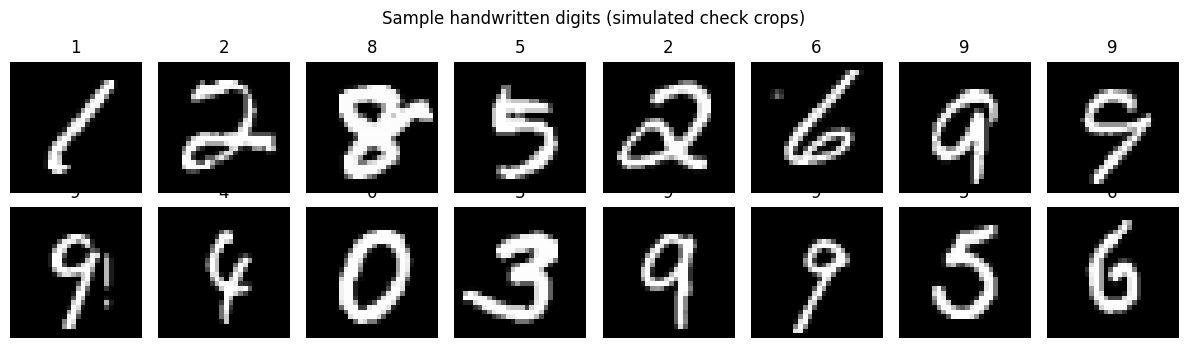

In [4]:
# Grid of sample "check-style" digits
examples = iter(train_loader)
images, labels = next(examples)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for i, ax in enumerate(axes.flat):
    img = images[i].squeeze() * 0.3081 + 0.1307  # undo normalization for display
    ax.imshow(img, cmap="gray")
    ax.set_title(str(labels[i].item()))
    ax.axis("off")
plt.suptitle("Sample handwritten digits (simulated check crops)")
plt.tight_layout()
plt.show()


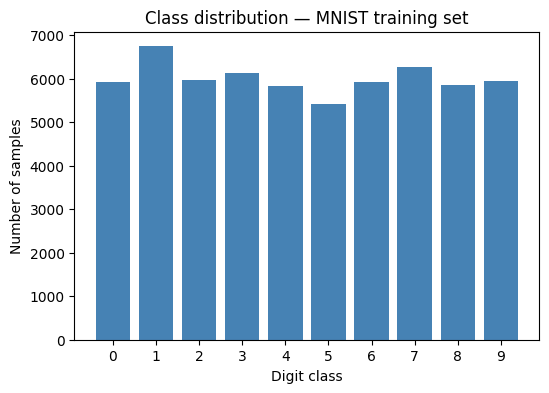

Digit 0: 5923 samples
Digit 1: 6742 samples
Digit 2: 5958 samples
Digit 3: 6131 samples
Digit 4: 5842 samples
Digit 5: 5421 samples
Digit 6: 5918 samples
Digit 7: 6265 samples
Digit 8: 5851 samples
Digit 9: 5949 samples


In [5]:
# Class distribution across the training set
train_targets = train_dataset.targets.numpy()
classes, counts = np.unique(train_targets, return_counts=True)

plt.figure(figsize=(6, 4))
plt.bar(classes, counts, color="steelblue")
plt.xlabel("Digit class")
plt.ylabel("Number of samples")
plt.title("Class distribution — MNIST training set")
plt.xticks(classes)
plt.show()

for c, n in zip(classes, counts):
    print(f"Digit {c}: {n} samples")


## 2. Architecture Design


In [6]:
class DigitMLP(nn.Module):
    def __init__(self, input_dim=28*28, hidden1=256, hidden2=128, num_classes=10, dropout=0.2):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        logits = self.fc3(x)   # raw scores; CrossEntropyLoss applies log-softmax internally
        return logits

model = DigitMLP().to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")


DigitMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)
Trainable parameters: 235,146


## 3. Model Training & Evaluation


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
NUM_EPOCHS = 10

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total


In [8]:
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    test_loss, test_acc = evaluate(model, test_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"test_loss={test_loss:.4f} test_acc={test_acc:.4f}")


Epoch  1/10 | train_loss=0.3176 train_acc=0.9034 | test_loss=0.1278 test_acc=0.9623
Epoch  2/10 | train_loss=0.1335 train_acc=0.9584 | test_loss=0.0903 test_acc=0.9714
Epoch  3/10 | train_loss=0.0972 train_acc=0.9692 | test_loss=0.0787 test_acc=0.9773
Epoch  4/10 | train_loss=0.0799 train_acc=0.9753 | test_loss=0.0678 test_acc=0.9780
Epoch  5/10 | train_loss=0.0676 train_acc=0.9782 | test_loss=0.0729 test_acc=0.9776
Epoch  6/10 | train_loss=0.0597 train_acc=0.9811 | test_loss=0.0641 test_acc=0.9816
Epoch  7/10 | train_loss=0.0552 train_acc=0.9826 | test_loss=0.0720 test_acc=0.9796
Epoch  8/10 | train_loss=0.0492 train_acc=0.9839 | test_loss=0.0663 test_acc=0.9811
Epoch  9/10 | train_loss=0.0448 train_acc=0.9857 | test_loss=0.0655 test_acc=0.9814
Epoch 10/10 | train_loss=0.0424 train_acc=0.9862 | test_loss=0.0645 test_acc=0.9833


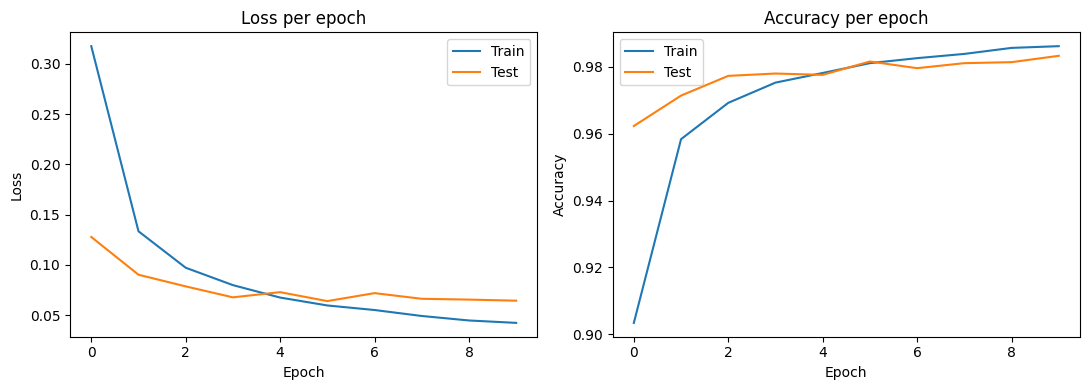

In [9]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["test_loss"], label="Test")
axes[0].set_title("Loss per epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["test_acc"], label="Test")
axes[1].set_title("Accuracy per epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


### Final evaluation on the 10,000 unseen test images

In [10]:
final_test_loss, final_test_acc = evaluate(model, test_loader, criterion)
print(f"Final Test Loss:     {final_test_loss:.4f}")
print(f"Final Test Accuracy: {final_test_acc*100:.2f}%")


Final Test Loss:     0.0645
Final Test Accuracy: 98.33%


## 4. Custom Inference Pipeline


In [11]:
def predict_digit(model, image, device=device):
    model.eval()

    if isinstance(image, np.ndarray):
        image = torch.from_numpy(image).float()

    if image.dim() == 2:            # (28, 28)
        image = image.unsqueeze(0).unsqueeze(0)
    elif image.dim() == 3:          # (1, 28, 28)
        image = image.unsqueeze(0)

    image = image.to(device)

    with torch.no_grad():
        logits = model(image)
        probs = F.softmax(logits, dim=1).squeeze(0).cpu().numpy()
        predicted_digit = int(np.argmax(probs))

    return predicted_digit, probs


### Demo: run the inference pipeline on a few test images

Image 0: true=7, predicted=7
  Confidence scores: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
Image 1: true=2, predicted=2
  Confidence scores: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
Image 2: true=1, predicted=1
  Confidence scores: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
Image 3: true=0, predicted=0
  Confidence scores: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Image 4: true=4, predicted=4
  Confidence scores: [0.    0.    0.    0.    0.999 0.    0.    0.    0.    0.001]


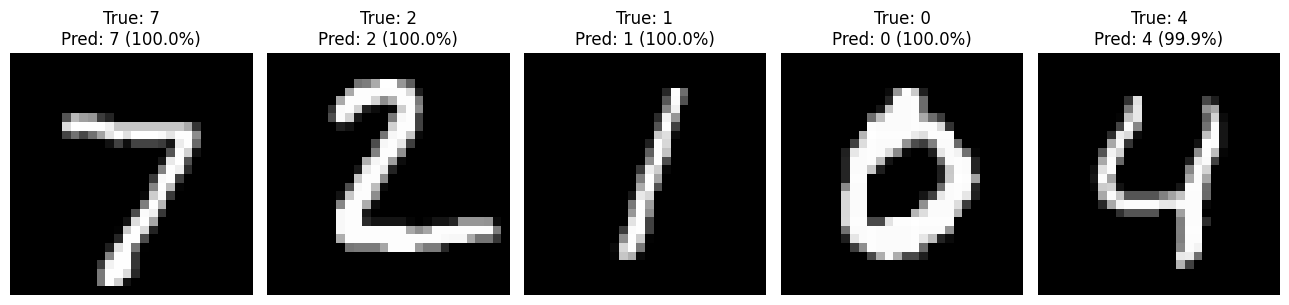

In [12]:
sample_images, sample_labels = next(iter(test_loader))

fig, axes = plt.subplots(1, 5, figsize=(13, 3))
for i in range(5):
    img = sample_images[i]
    true_label = sample_labels[i].item()

    pred_digit, confidences = predict_digit(model, img)

    display_img = img.squeeze().numpy() * 0.3081 + 0.1307
    axes[i].imshow(display_img, cmap="gray")
    axes[i].set_title(f"True: {true_label}\nPred: {pred_digit} ({confidences[pred_digit]*100:.1f}%)")
    axes[i].axis("off")

    print(f"Image {i}: true={true_label}, predicted={pred_digit}")
    print(f"  Confidence scores: {np.round(confidences, 3)}")

plt.tight_layout()
plt.show()


## 5. Technical Research & Conceptual Analysis


### Topic A: Escaping Traps (Local Minima vs. Saddle Points)

**Why true local minima are rare in high dimensions**

A point is a local minimum only if *every* direction you could perturb the weights in leads
uphill. In a 2D loss surface there are only two directions to check, so a "bowl" trapping the
optimizer is plausible. A modern MLP has thousands to millions of parameters, meaning a
critical point (where the gradient is zero) lives in a space with that many independent
directions. For a critical point to be a true local minimum, the loss must curve *upward*
along **all** of those directions simultaneously — equivalently, the Hessian (the matrix of
second derivatives) must be positive-definite in every eigen-direction at once. Random matrix
theory suggests that as dimensionality grows, the odds of a critical point having all-positive
curvature shrink rapidly, while the odds of a "mixed" signature — some directions curving up,
some curving down — grow. That mixed-signature critical point is exactly a **saddle point**.
So in a high-dimensional network, a critical point is overwhelmingly more likely to be a saddle
than a genuine local minimum.

**Saddle points and plateaus as the real bottleneck**

At a saddle point the gradient is zero (so vanilla gradient descent slows to a crawl nearby),
but there's always at least one descending direction available — the optimizer isn't
permanently stuck, it just needs enough noise or curvature information to find that direction
and slide off. Flat plateaus are related but distinct: broad, nearly-zero-gradient regions
where the loss doesn't have a clean escape direction nearby, just a very shallow slope. In
practice, these saddle regions and plateaus are what cause training to visibly stall for many
steps — not because the network is caught in a bad final answer, but because the gradient
signal near a saddle is too weak to make fast progress.

**How mini-batch noise helps**

Full-batch gradient descent computes the *exact* gradient of the loss averaged over the whole
dataset, so at a saddle point that exact gradient really is (close to) zero and progress
genuinely stalls. Mini-batch SGD instead computes a noisy estimate of the gradient from a small
random subset of the data each step. That noise means the gradient computed at any given step
is very unlikely to be exactly zero even when the *true* full-dataset gradient is — the
stochastic estimate effectively perturbs the optimizer off the saddle in some random direction.
Once nudged even slightly off a saddle, the descending directions that were available all along
start pulling the weights downhill again. The same noise helps on flat plateaus: instead of
following one deterministic (and possibly very slow) path, the optimizer bounces around
slightly, increasing the chance it stumbles onto a direction with a steeper drop. This is part
of why SGD-style training, despite being "noisier" than full-batch gradient descent, often
converges to good solutions faster in practice on large networks.

### Topic B: Comparative Analysis of Optimizers

**Stochastic Gradient Descent (SGD)**

Standard SGD updates each weight by moving a fixed step (the learning rate) in the direction
opposite the estimated gradient: `w ← w - lr * grad`. Every parameter shares the same learning
rate, and the update only ever looks at the *current* gradient with no memory of past updates.
This causes two well-known problems. First, in narrow, steep ravines — common in loss surfaces
where curvature is very different across directions — the gradient points mostly toward the
steep walls rather than along the gentle direction that actually leads to the minimum, so SGD
zig-zags back and forth across the ravine instead of moving efficiently along it. Second, in
very flat regions the gradient is tiny, so with no memory of prior momentum, progress crawls.

**SGD with Momentum**

Momentum addresses this with a simple physical analogy: imagine a heavy ball rolling downhill
instead of a weightless point that reacts only to the instantaneous slope. The update keeps a
running "velocity" that accumulates a fraction of previous gradients: `v ← β*v + grad`, then
`w ← w - lr*v`. Because the ball has inertia, oscillations across a narrow ravine — which point
in opposite directions on alternating steps — tend to cancel out in the accumulated velocity,
while the consistent downhill component (along the ravine's length) keeps reinforcing itself
and grows. The same inertia carries the ball through flat plateaus and shallow saddle regions
where the instantaneous gradient alone would barely move it.

**Adaptive Optimizers (RMSprop & Adam)**

"Adapting the learning rate per parameter" means each individual weight gets its own effective
step size, scaled by how large that weight's gradients have typically been. RMSprop tracks a
running average of the squared gradient for each parameter and divides the update by its square
root, so parameters with a history of large, volatile gradients get smaller effective steps
(damping instability), while parameters with small, consistent gradients get relatively larger
steps (speeding up otherwise-slow directions). Adam combines this per-parameter adaptive
scaling (like RMSprop) with momentum (like SGD+Momentum), tracking both a running mean and a
running variance of the gradients.

Adam is typically the default choice for quick baseline experimentation because it is
comparatively insensitive to the initial learning rate choice and tends to converge quickly
with minimal tuning — useful when you just want a working baseline fast. However, well-tuned
SGD with Momentum can still outperform Adam on final generalization in some benchmark settings
(this shows up often in image classification with CNNs, for example) — Adam's aggressive
per-parameter adaptivity can sometimes settle into sharper minima that generalize slightly
worse, whereas plain SGD with a carefully tuned learning-rate schedule and momentum can find
flatter minima that generalize better, at the cost of needing more manual tuning effort.